# In-Class Exercises: Vectorization & Broadcasting


## Setup

In [2]:
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import Callable

%matplotlib inline

# Set random seed for reproducibility
np.random.seed(42)

print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print("All imports succeeded.")

NumPy version: 2.5.1
Matplotlib version: 3.11.1
All imports succeeded.


## Element-Wise

In [4]:
# Create two arrays
a = np.array([1, 2, 3, 4, 5])
b = np.array([10, 20, 30, 40, 50])
a,b, a.shape, b.shape

(array([1, 2, 3, 4, 5]), array([10, 20, 30, 40, 50]), (5,), (5,))

In [6]:
c = a + b
c, c.shape

(array([11, 22, 33, 44, 55]), (5,))

In [9]:
c = a * b
c, c.shape

(array([ 10,  40,  90, 160, 250]), (5,))

## Broadcasting

In [10]:
scalar = 3
a = np.array([1, 2, 3, 4, 5])

3 * a

array([ 3,  6,  9, 12, 15])

In [11]:
b = np.array([3, 3, 3, 3, 3])
a = np.array([1, 2, 3, 4, 5])

b * a

array([ 3,  6,  9, 12, 15])

In [14]:
a = np.array([
                [1, 2, 3],
                [4, 5, 6]
            ])
b = np.array([10, 20, 30])
a + b

array([[11, 22, 33],
       [14, 25, 36]])

## Dot Product

In [15]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

np.dot(a, b)

np.int64(32)

In [16]:
result = a @ b
result

np.int64(32)

## Matrix Multiplication

In [18]:
# Create two matrices
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])  # Shape: (2, 3)

B = np.array([
    [7, 8],
    [9, 10],
    [11, 12]
])  # Shape: (3, 2)

A.shape, B.shape

((2, 3), (3, 2))

In [19]:
C = np.matmul(A, B)
C.shape, C

((2, 2),
 array([[ 58,  64],
        [139, 154]]))

In [ ]:
np.array([1, 2, 3]) @ np.array([7, 9, 11])

np.int64(58)

In [ ]:
np.array([4, 5, 6]) @ np.array([8, 10, 12])

np.int64(154)

## Common Errors

In [23]:
A = np.array([[1, 2], [3, 4]])        # (2, 2)
B = np.array([[5, 6, 7], [8, 9, 10]]) # (2, 3)
A, B

(array([[1, 2],
        [3, 4]]),
 array([[ 5,  6,  7],
        [ 8,  9, 10]]))

In [24]:
result1 = A @ B
result1, result1.shape

(array([[21, 24, 27],
        [47, 54, 61]]),
 (2, 3))

In [30]:
try:    
    result2 = B.T @ A
    print(result2, result2.shape)
except ValueError as e:
    print(f"\nError with B @ A: Inner dimensions don't match")
    print(f"B.shape={B.shape}, A.shape={A.shape}")
    print(f"Inner dims: {B.shape[1]} ≠ {A.shape[0]}")

[[29 42]
 [33 48]
 [37 54]] (3, 2)


## The Artifical Neuron

A single neuron computes:

$$
\text{output} = \text{activation}\left(\sum_{i=1}^{n} w_i x_i + b\right)
$$


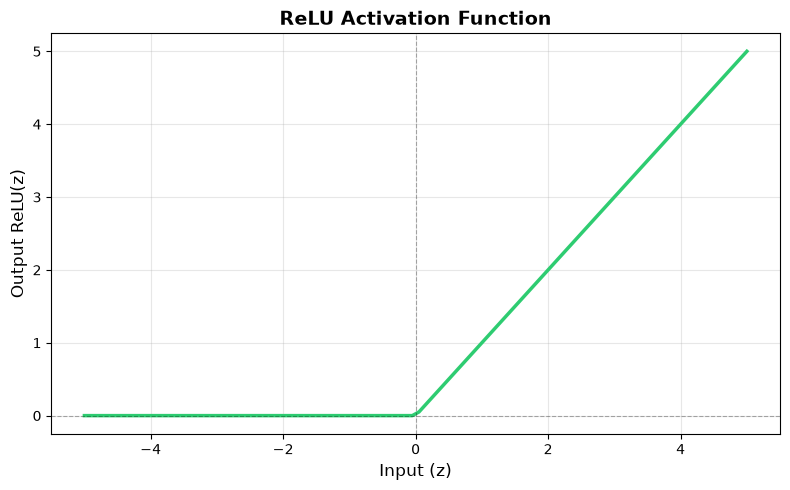

In [31]:
# activation function

def relu(x: np.ndarray) -> np.ndarray:
    """ReLU activation: max(0, x)"""
    return np.maximum(0, x)

# Visualize ReLU
x = np.linspace(-5, 5, 100)
y = relu(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y, linewidth=2.5, color='#2ecc71')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.3)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.3)
plt.grid(alpha=0.3)
plt.title('ReLU Activation Function', fontsize=14, fontweight='bold')
plt.xlabel('Input (z)', fontsize=12)
plt.ylabel('Output ReLU(z)', fontsize=12)
plt.tight_layout()
plt.show()

In [32]:
# inputs, weights, bias

inputs = np.array([1.0, 2.0, 3.0])    # 3 input features
weights = np.array([0.5, -0.3, 0.8])  # Learned weights
bias = 0.1                             # Learned bias

# output of the neuron
z = np.dot(weights, inputs) + bias

output = relu(z)

print(f"z = {z:.4f}")
print(f"ReLU(z) = {output:.4f}")


z = 2.4000
ReLU(z) = 2.4000


## A Layer of Neurons

In [33]:
# Define dimensions
batch_size = 4    # Process 4 examples at once
input_dim = 3     # Each example has 3 features
output_dim = 5    # Layer has 5 neurons

# Create example data
X = np.random.randn(batch_size, input_dim)  # (4, 3)
W = np.random.randn(input_dim, output_dim)  # (3, 5)
b = np.random.randn(output_dim)             # (5,)

X, W, b

(array([[ 0.49671415, -0.1382643 ,  0.64768854],
        [ 1.52302986, -0.23415337, -0.23413696],
        [ 1.57921282,  0.76743473, -0.46947439],
        [ 0.54256004, -0.46341769, -0.46572975]]),
 array([[ 0.24196227, -1.91328024, -1.72491783, -0.56228753, -1.01283112],
        [ 0.31424733, -0.90802408, -1.4123037 ,  1.46564877, -0.2257763 ],
        [ 0.0675282 , -1.42474819, -0.54438272,  0.11092259, -1.15099358]]),
 array([ 0.37569802, -0.60063869, -0.29169375, -0.60170661,  1.85227818]))

In [34]:
# Forward pass
Z = X @ W + b     # Broadcasting adds bias to each row
Y = relu(Z)

print(f"\n  Z = X @ W + b: {Z.shape}")
print(f"  Y = ReLU(Z):   {Y.shape}")


  Z = X @ W + b: (4, 5)
  Y = ReLU(Z):   (4, 5)


In [35]:
Z, Y

(array([[ 0.49617216, -2.34823782, -1.30580412, -1.0118064 ,  0.63492209],
        [ 0.65482086, -2.96841852, -2.46063932, -1.82724499,  0.63206257],
        [ 0.96726949, -3.6500818 , -3.84398326, -0.41696383,  0.61989573],
        [ 0.32989941, -0.55436606, -0.31954349, -1.63764888,  1.94343718]]),
 array([[0.49617216, 0.        , 0.        , 0.        , 0.63492209],
        [0.65482086, 0.        , 0.        , 0.        , 0.63206257],
        [0.96726949, 0.        , 0.        , 0.        , 0.61989573],
        [0.32989941, 0.        , 0.        , 0.        , 1.94343718]]))

## Performance Characteristics

In [36]:
# Create large arrays
size = 1_000_000
a = np.random.rand(size)
b = np.random.rand(size)

# Method 1: Python loop
start = time.perf_counter()
result_loop = []
for i in range(size):
    result_loop.append(a[i] * b[i])
loop_time = time.perf_counter() - start

# Method 2: Vectorized
start = time.perf_counter()
result_vectorized = a * b
vectorized_time = time.perf_counter() - start

print(f"Loop time:       {loop_time*1000:.2f} ms")
print(f"Vectorized time: {vectorized_time*1000:.2f} ms")
print(f"\nSpeedup: {loop_time / vectorized_time:.1f}x faster")
print(f"Results match: {np.allclose(result_loop, result_vectorized)}")

Loop time:       95.97 ms
Vectorized time: 0.74 ms

Speedup: 129.3x faster
Results match: True
